# Customer Churn Analysis Using Seaborn

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
data = pd.read_csv('Telco-Customer-Churn.csv')

In [3]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,Yes,DSL,No,...,No,No,No,No,month to month,Yes,Electronic check,$29.85,NaN,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.7,151.65,Yes


In [4]:
data.shape

(7048, 21)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7048 entries, 0 to 7047
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        7048 non-null   object
 1   gender            7048 non-null   object
 2   SeniorCitizen     7048 non-null   int64 
 3   Partner           7048 non-null   object
 4   Dependents        7048 non-null   object
 5   tenure            7048 non-null   int64 
 6   PhoneService      7048 non-null   object
 7   MultipleLines     7048 non-null   object
 8   InternetService   7048 non-null   object
 9   OnlineSecurity    7048 non-null   object
 10  OnlineBackup      7048 non-null   object
 11  DeviceProtection  7048 non-null   object
 12  TechSupport       7048 non-null   object
 13  StreamingTV       7048 non-null   object
 14  StreamingMovies   7048 non-null   object
 15  Contract          7048 non-null   object
 16  PaperlessBilling  7048 non-null   object
 17  PaymentMethod 

In [6]:
data.isnull().sum()

customerID            0
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
Contract              0
PaperlessBilling      0
PaymentMethod         0
MonthlyCharges        0
TotalCharges        126
Churn                 0
dtype: int64

In [8]:
data.isnull().mean()*100

customerID          0.000000
gender              0.000000
SeniorCitizen       0.000000
Partner             0.000000
Dependents          0.000000
tenure              0.000000
PhoneService        0.000000
MultipleLines       0.000000
InternetService     0.000000
OnlineSecurity      0.000000
OnlineBackup        0.000000
DeviceProtection    0.000000
TechSupport         0.000000
StreamingTV         0.000000
StreamingMovies     0.000000
Contract            0.000000
PaperlessBilling    0.000000
PaymentMethod       0.000000
MonthlyCharges      0.000000
TotalCharges        1.787741
Churn               0.000000
dtype: float64

In [10]:
data.duplicated().sum()

np.int64(5)

In [11]:
data.drop_duplicates(inplace=True)

In [12]:
data.duplicated().sum()

np.int64(0)

In [13]:
data.dtypes

customerID          object
gender              object
SeniorCitizen        int64
Partner             object
Dependents          object
tenure               int64
PhoneService        object
MultipleLines       object
InternetService     object
OnlineSecurity      object
OnlineBackup        object
DeviceProtection    object
TechSupport         object
StreamingTV         object
StreamingMovies     object
Contract            object
PaperlessBilling    object
PaymentMethod       object
MonthlyCharges      object
TotalCharges        object
Churn               object
dtype: object

In [19]:
pd.to_numeric(data['MonthlyCharges'], errors='coerce').isnull().sum()

np.int64(1007)

In [20]:
data['MonthlyCharges'].isnull().sum()

np.int64(0)

In [23]:
data['MonthlyCharges'].value_counts()

MonthlyCharges
20.05     52
19.85     41
20.15     37
19.65     37
19.55     36
          ..
113.25     1
$29.75     1
42.3       1
56.95      1
$29.85     1
Name: count, Length: 2168, dtype: int64

In [27]:
data['MonthlyCharges'].replace(r'[^0-9.]','',regex=True).isnull().sum()

np.int64(0)

In [28]:
data['MonthlyCharges']=data['MonthlyCharges'].replace(r'[^0-9.]','',regex=True)

In [29]:
pd.to_numeric(data['MonthlyCharges'], errors='coerce').isnull().sum()

np.int64(0)

In [30]:
data['MonthlyCharges']= pd.to_numeric(data['MonthlyCharges'], errors='coerce')

# 

In [31]:
data['TotalCharges'].isnull().sum()

np.int64(125)

In [32]:
pd.to_numeric(data['TotalCharges'], errors='coerce').isnull().sum()

np.int64(133)

In [41]:
data['TotalCharges'].value_counts().sample(10)

TotalCharges
1493.2     2
4492.9     1
1013.6     1
6962.85    1
5538.35    1
713        1
3539.25    1
1636.95    1
1028.9     1
389.6      1
Name: count, dtype: int64

In [42]:
data['TotalCharges']= pd.to_numeric(data['TotalCharges'], errors='coerce')

In [ ]:
8797325416

In [44]:
data["TotalCharges"] = data["TotalCharges"].fillna(data["TotalCharges"].median())

In [45]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [46]:
data.duplicated().sum()

np.int64(0)

# 

# 

#### 1. How many customers left the company?
- How many customers stayed with the company and how many left?

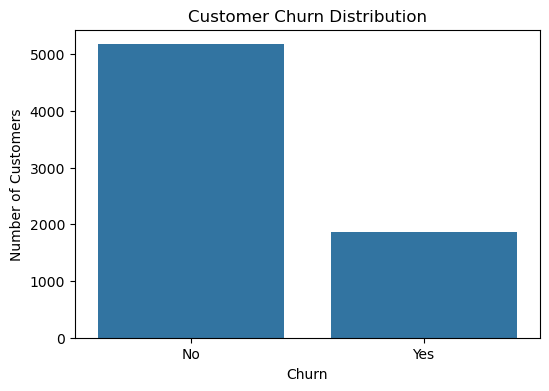

In [56]:
plt.figure(figsize=(6,4))
sns.countplot(data=data,x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [60]:
Churn_count_data = data['Churn'].value_counts().reset_index()
Churn_count_data

,Churn,count
0,No,5174
1,Yes,1869


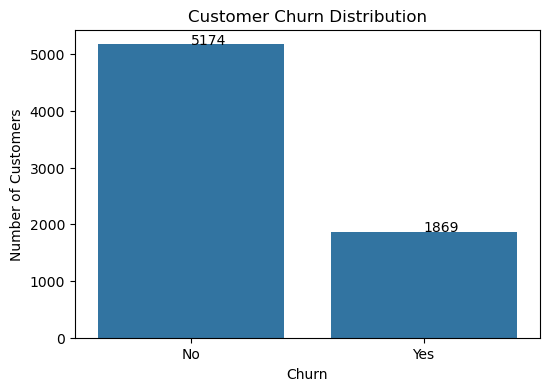

In [64]:
plt.figure(figsize=(6,4))
sns.countplot(data=data,x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
for i, v in enumerate(Churn_count_data['count']):
    plt.annotate(v, xy=(i,v))
plt.show()

observation:
- most customers are stayed with the company.
- smaller number of customers left.

# 

#### 2. What is the distribution of Monthly Charges?
- How much do customers pay each month?

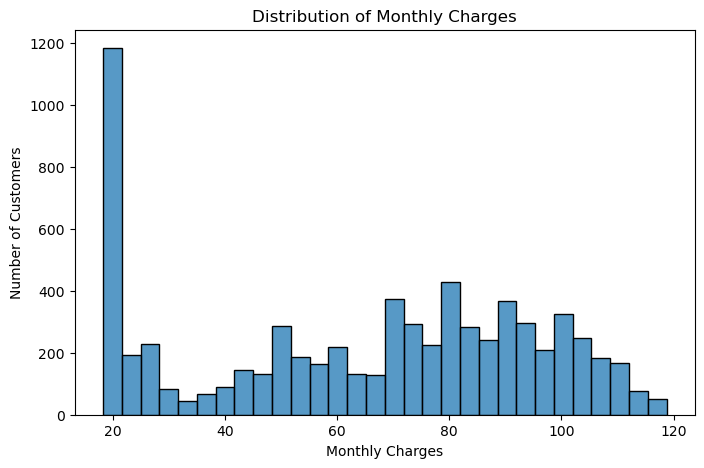

In [66]:
plt.figure(figsize=(8,5))
sns.histplot(data=data,x="MonthlyCharges",bins=30)
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.show()

Observation:
- Most customers pay between $20  -   $30 per month.
-  Another large group of customers pays between $70 -  $100 per month.
-  Monthly charges range from approximately $18 -- $120.

#### 3. How long do customers stay with the company?
- What is the distribution of customer tenure?

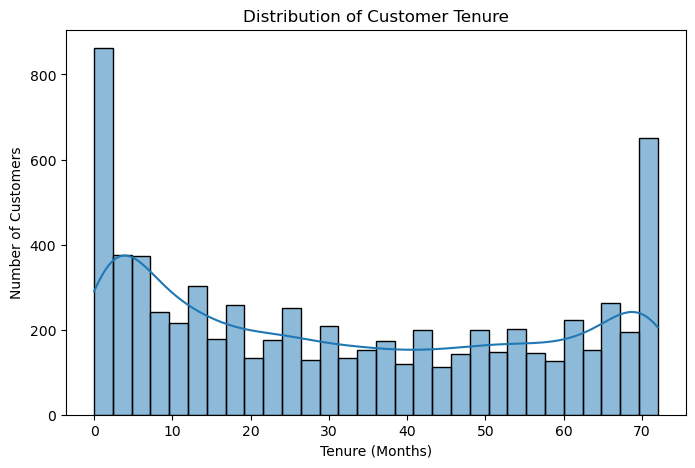

In [72]:
plt.figure(figsize=(8,5))
sns.histplot(data=data,x="tenure",bins=30,kde=True)
plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.show()

Observation:
- Most customers are new (tenure 0–8 months) 
- The second largest group of customers has a tenure of 65–72 months, indicating many long-term customers.
- Fewer customers have a tenure between 10 and 60 months.
- The distribution shows two clear customer groups: new customers and loyal long-term customers

# 

#### 4. Are there any outliers in Monthly Charges?
- Are some customers paying unusually high or low monthly charges?

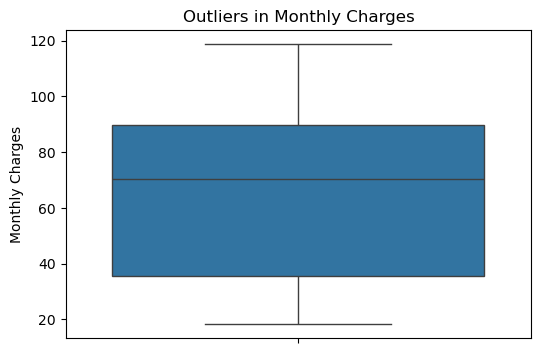

In [82]:
plt.figure(figsize=(6,4))
sns.boxplot(data=data,y="MonthlyCharges")
plt.title("Outliers in Monthly Charges")
plt.ylabel("Monthly Charges")
plt.show()

###### Observation:
- No significant outliers are present.
- Monthly charges range from 18 - 118.
- The median monthly charge is around $70.
- The middle 50% of customers pay between 35 - 90 per month.

# 

#### 5. Which contract type has the most customers?
- Which contract plan is the most popular among customers?

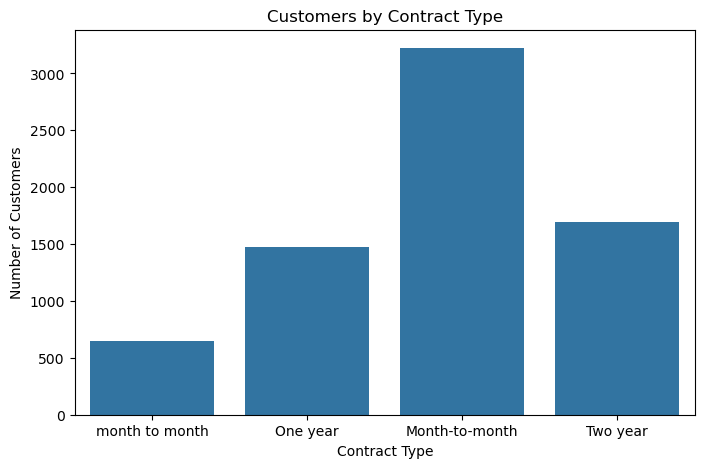

In [87]:
plt.figure(figsize=(8,5))
sns.countplot(data=data,x="Contract")
plt.title("Customers by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

In [101]:
data["Contract"] = data["Contract"].str.title().str.replace('Month To Month' ,'Month-To-Month')

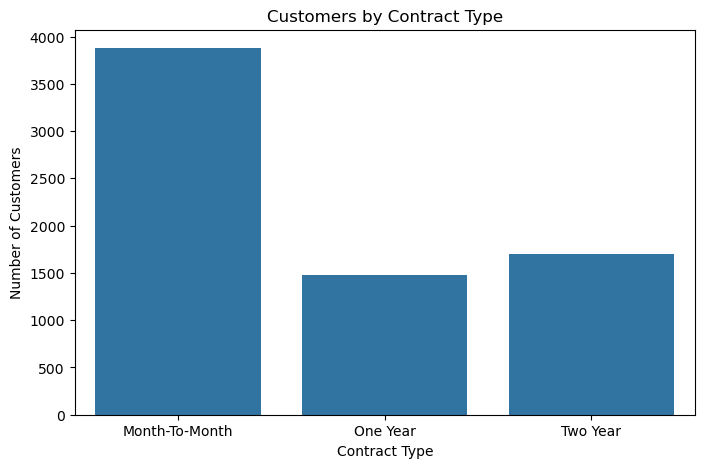

In [102]:
plt.figure(figsize=(8,5))
sns.countplot(data=data,x="Contract")
plt.title("Customers by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

Observation:
- Month-to_Month Contract have more customer  
 ( Month-to_Month contract plan is the most popular among customers)

# 

#### 6. Does Contract Type affect Customer Churn?
- Which contract type has the highest customer churn?

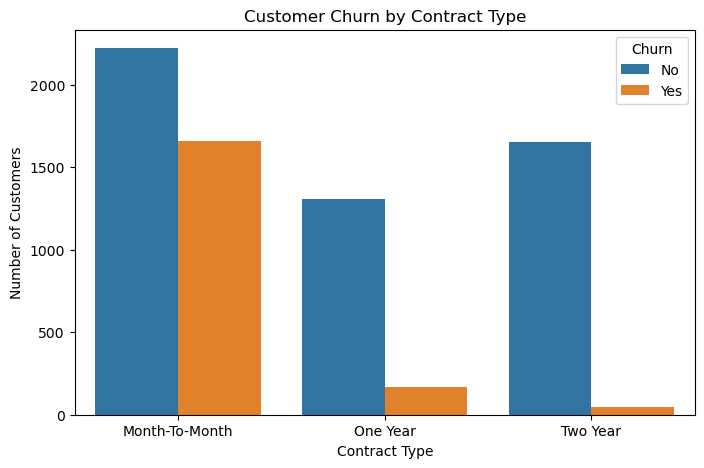

In [106]:
plt.figure(figsize=(8,5))
sns.countplot(data=data,x="Contract",hue="Churn")
plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

obsevartion :
- Month to Month contract type has the highest customer churn. 
- Two Year contract type has the lowest customer churn.

#### 7. Does Gender affect Customer Churn?
- Is customer churn different for male and female customers?

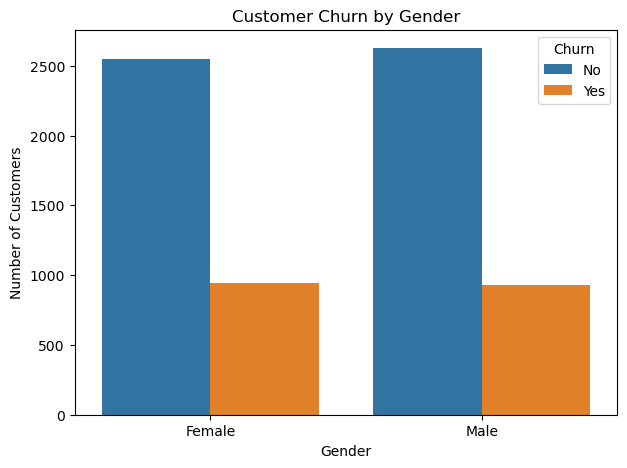

In [113]:
plt.figure(figsize=(7,5))
sns.countplot(data=data,x="gender",hue="Churn")
plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

obsevation :
- No customer churn different for male and female customers
- Both gender have equal customer churn

# 

#### 8. Do Senior Citizens leave more?
- Are senior citizens more likely to leave the company?

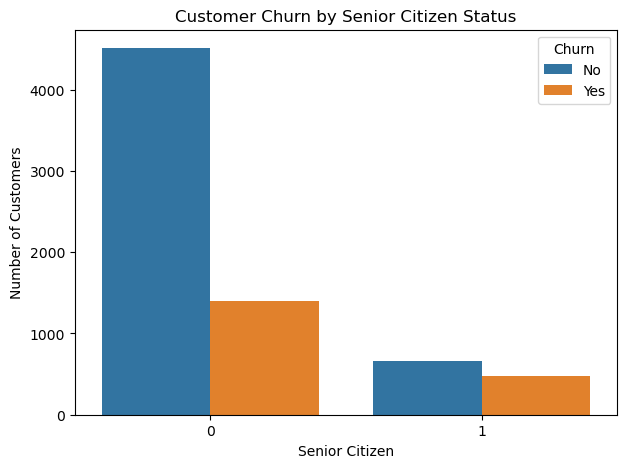

In [121]:
plt.figure(figsize=(7,5))
sns.countplot(data=data,x="SeniorCitizen",hue="Churn")
plt.title("Customer Churn by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")
plt.show()

# 

#### 9. Does having a Partner reduce Customer Churn?
- Are customers with a partner less likely to leave?

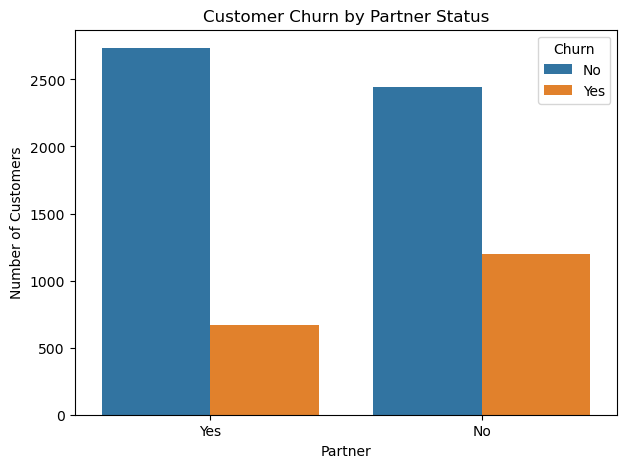

In [122]:
plt.figure(figsize=(7,5))
sns.countplot(data=data,x="Partner",hue="Churn")
plt.title("Customer Churn by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Number of Customers")
plt.show()

- Customers with a partner are less likely to leave the company.
- Customers without a partner have a higher churn rate.

# 

#### 10. Does having Dependents reduce Customer Churn?
- Are customers with dependents more likely to stay?

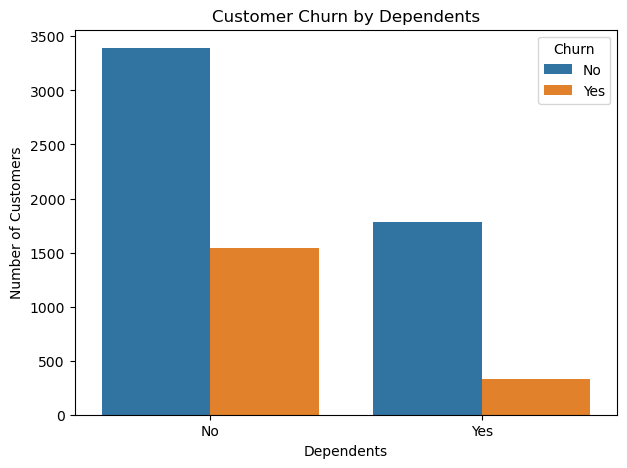

In [124]:
plt.figure(figsize=(7,5))
sns.countplot(data=data,x="Dependents",hue="Churn")
plt.title("Customer Churn by Dependents")
plt.xlabel("Dependents")
plt.ylabel("Number of Customers")
plt.show()

- Customers without dependents make up the largest customer group.
- More customers without dependents stay with the company.
- More customers without dependents also leave the company.